In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

In [66]:
trnImage = np.load('trnImage.npy')
trnLabel_fine = np.load('trnLabel_fine.npy')
tstImage = np.load('tstImage.npy')
tstLabel_fine = np.load('tstLabel_fine.npy')
trnLabel_coarse = np.load('trnLabel_coarse.npy')
tstLabel_coarse = np.load('tstLabel_coarse.npy')

Kernel - Linear = validation = 0.16
Test = 0.17

Kernel - RBF gamma 'scale' = validation = 0.25 Test = 0.25

Kernel - Poly = validation = 0.19 Test = 0.19

In [67]:
# Flatten the images to create a feature matrix
trnImage = np.moveaxis(trnImage, -1, 0)  # Rearrange axis to (50000, 32, 32, 3)
tstImage = np.moveaxis(tstImage, -1, 0)  # Same for the test dataset

#3D data into 1D feature vector
#32 x 32 x 3 = (50000, 3072)
train_flattened = trnImage.reshape((trnImage.shape[0], -1))
test_flattened = tstImage.reshape((tstImage.shape[0], -1))

print(f"Training images shape: {trnImage.shape}")
print(f"Training labels shape: {trnLabel_fine.shape}")

X_train, X_val, y_train, y_val = train_test_split(
    train_flattened, trnLabel_fine, test_size=0.2, random_state=42, stratify=trnLabel_fine
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(test_flattened)

#Fully connected neural network implementation
train_reshaped = train_flattened.reshape((-1, 32, 32, 3))
test_reshaped = test_flattened.reshape((-1, 32, 32, 3))

y_train_one_hot = tf.keras.utils.to_categorical(y_train, num_classes=100) 
y_val_one_hot = tf.keras.utils.to_categorical(y_val, num_classes=100)
y_test_one_hot = tf.keras.utils.to_categorical(tstLabel_fine, num_classes=100)

Shapes of datasets:
Training images shape: (50000, 32, 32, 3)
Training labels shape: (50000,)


Validation Accuracy: 0.25
Classification Report for Validation Set:
              precision    recall  f1-score   support

           0       0.45      0.45      0.45       100
           1       0.24      0.37      0.29       100
           2       0.17      0.18      0.17       100
           3       0.13      0.16      0.14       100
           4       0.08      0.14      0.10       100
           5       0.17      0.25      0.20       100
           6       0.20      0.14      0.16       100
           7       0.10      0.14      0.11       100
           8       0.25      0.22      0.23       100
           9       0.43      0.29      0.35       100
          10       0.14      0.06      0.08       100
          11       0.23      0.12      0.16       100
          12       0.20      0.16      0.18       100
          13       0.18      0.21      0.19       100
          14       0.25      0.19      0.22       100
          15       0.14      0.08      0.10       100
          16 

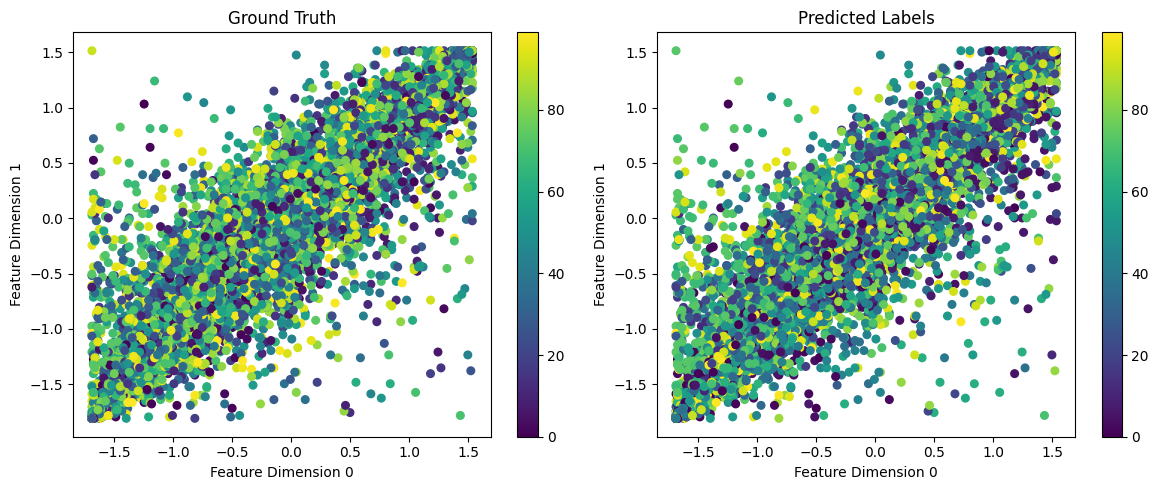

In [3]:
#SVM Model
svm_model = SVC(kernel='rbf', gamma='scale', degree=3, random_state=42, class_weight='balanced')
svm_model.fit(X_train_scaled, y_train)

y_val_pred = svm_model.predict(X_val_scaled)
val_accuracy = svm_model.score(X_val_scaled, y_val)
print(f"Validation Accuracy: {val_accuracy:.2f}")
print("Classification Report for Validation Set:")
print(classification_report(y_val, y_val_pred, zero_division=1))

y_test_pred = svm_model.predict(X_test_scaled)
test_accuracy = svm_model.score(X_test_scaled, tstLabel_fine)
print(f"Test Accuracy: {test_accuracy:.2f}")
print("Classification Report for Test Set:")
print(classification_report(tstLabel_fine, y_test_pred, zero_division=1))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
scatter1 = axes[0].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=tstLabel_fine, cmap='viridis', s=30)
axes[0].set_title("Ground Truth")
axes[0].set_xlabel("Feature Dimension 0")
axes[0].set_ylabel("Feature Dimension 1")
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test_pred, cmap='viridis', s=30)
axes[1].set_title("Predicted Labels")
axes[1].set_xlabel("Feature Dimension 0")
axes[1].set_ylabel("Feature Dimension 1")
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

Test 1:
LR = 0.0001
Activation = Relu
Layers = all 512 (3 layers)
epochs = 15
batch = 32
Test Loss: 3.9950, Test Accuracy: 0.2457
Using same values with leaky relu = 0.2458

Test 2:
Lr = 0.001
layers = all 512 (3 layers)
Activation = Relu
Epochs = 20
Batch = 32
Test Loss: 4.0437, Test Accuracy: 0.1982

Test 3:
Lr = 0.0001
layers = all 1024 (3 layers)
Activation = leaky relu
Epochs = 15
Batch = 32
Test Loss: 4.7150, Test Accuracy: 0.2446

Test 4: 
Test 1 but added Flatten line
Test Loss: 3.9897, Test Accuracy: 0.2467

Test 5:
Increased Epochs: 35
Batch size = 64
leaky_relu
Test accuracy 0.2319

Test 6:
Overfitting,
Added dropout layers between each hidden layer
If accuracy decreases, then I will increase the layers such that it is 128, 256, 512 instead.
Test Loss: 3.2654, Test Accuracy: 0.2379

Test 7:
Removed 2 layers,
Only have 1 dense layer thats 512
Test Loss: 3.4653, Test Accuracy: 0.2062

Test 8:
added 3 layers again
epochs 50 batch size 64
layer 128, 256, 512
Test Loss: 3.1355, Test Accuracy: 0.2514

Test 9:
layer 512, 512, 512
Test Loss: 3.0721, Test Accuracy: 0.2598

Test 10:
1024 1024 layers
Test Loss: 2.9636, Test Accuracy: 0.2953

Test 11:
3 layers 
starts increasing val_loss by 37th epoch
Test Loss: 3.2140, Test Accuracy: 0.3007

In [70]:
#Fully connected neural network
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(3072,)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1024, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1024, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1024, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(1024, activation=tf.nn.leaky_relu),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(100, activation=tf.nn.softmax)
])

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    mode='min',
    verbose=1,
    patience=3
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.CategoricalCrossentropy(),
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    X_train_scaled,
    y_train_one_hot,
    validation_data = (X_val_scaled, y_val_one_hot),
    epochs = 60,
    batch_size = 64
)

test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test_one_hot, verbose = 1)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")

Epoch 1/55
625/625 ━━━━━━━━━━━━━━━━━━━━ 32s 44ms/step - accuracy: 0.0386 - loss: 4.9554 - val_accuracy: 0.1209 - val_loss: 3.7796
Epoch 2/55
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.0944 - loss: 3.9921 - val_accuracy: 0.1548 - val_loss: 3.6074
Epoch 3/55
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.1126 - loss: 3.8417 - val_accuracy: 0.1679 - val_loss: 3.4937
Epoch 4/55
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.1269 - loss: 3.7633 - val_accuracy: 0.1764 - val_loss: 3.4674
Epoch 5/55
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.1355 - loss: 3.6732 - val_accuracy: 0.1920 - val_loss: 3.4014
Epoch 6/55
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.1493 - loss: 3.6126 - val_accuracy: 0.1960 - val_loss: 3.3565
Epoch 7/55
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.1610 - loss: 3.5397 - val_accuracy: 0.1986 - val_loss: 3.3256
Epoch 8/55
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - accuracy: 0.1647 - loss: 3.4896 - 

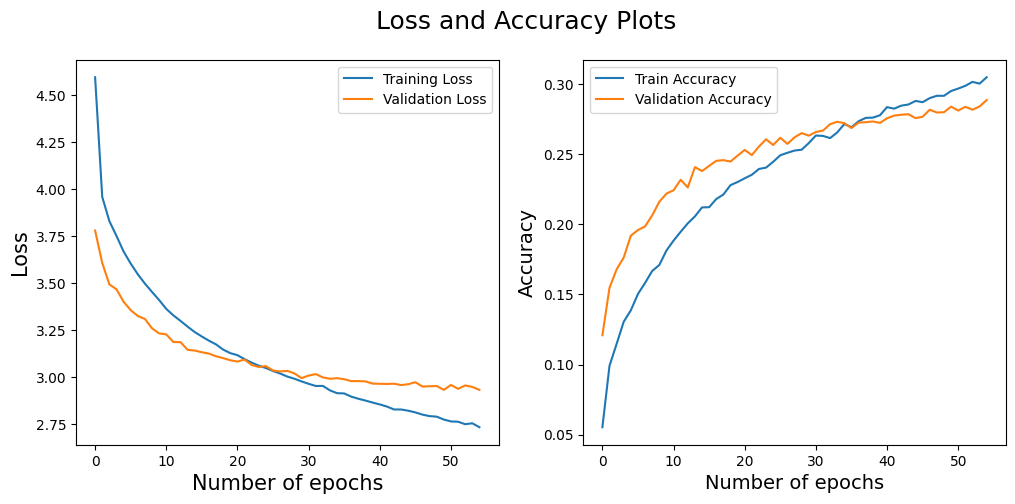

In [71]:
#plot to visualize the loss and accuracy against number of epochs
plt.figure(figsize=(12,5))

plt.suptitle('Loss and Accuracy Plots', fontsize=18)

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Number of epochs', fontsize=15)
plt.ylabel('Loss', fontsize=15)

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Number of epochs', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.show()

The confusion matrix you are looking at is for Class 0, and it's displayed in a binary format. The matrix compares the actual labels (True labels) and predicted labels, specifically for Class 0. Here's what the matrix represents:

Confusion Matrix Interpretation:
The matrix is a 2x2 grid:

Rows represent the True labels (the actual class of the sample).
Columns represent the Predicted labels (the class predicted by the model).
Breakdown of the entries:
True Negative (TN): The number in the top-left corner (9878) represents samples that are not class 0 and were correctly predicted as not class 0.
False Positive (FP): The number in the top-right corner (22) represents samples that are not class 0 but were incorrectly predicted as class 0.
False Negative (FN): The number in the bottom-left corner (53) represents samples that are class 0 but were incorrectly predicted as not class 0.
True Positive (TP): The number in the bottom-right corner (47) represents samples that are class 0 and were correctly predicted as class 0.
Meaning:
True Positives (47): 47 instances of Class 0 were correctly predicted by the model.
False Negatives (53): 53 instances of Class 0 were incorrectly predicted as not Class 0.
True Negatives (9878): 9878 instances that are not Class 0 were correctly predicted as not Class 0.
False Positives (22): 22 instances that are not Class 0 were incorrectly predicted as Class 0.
Implications:
The model performs well in predicting Class 0, with high true negatives and relatively few false positives. However, it struggles with identifying all true instances of Class 0, as evidenced by the false negatives (53).
This suggests that Class 0 might be underrepresented or hard to distinguish from other classes, which is common in many machine learning problems, especially with imbalanced datasets.

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


<Figure size 600x500 with 0 Axes>

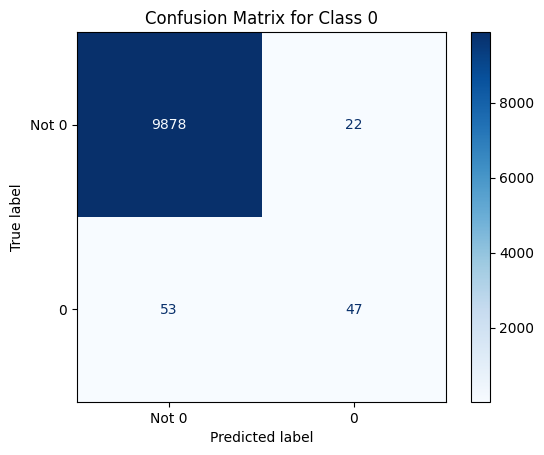

In [79]:
y_test_pred_fnn = model.predict(X_test_scaled)
y_test_pred_fnn = np.argmax(y_test_pred_fnn, axis=1)  # Convert one-hot to class labels

# True labels
y_test_true = np.argmax(y_test_one_hot, axis=1)

# Class of interest (e.g., class 0)
class_of_interest = 0

binary_true = (y_test_true == class_of_interest).astype(int)
binary_pred = (y_test_pred_fnn == class_of_interest).astype(int)

cm_binary = confusion_matrix(binary_true, binary_pred)

# Create the confusion matrix display object for the binary classification
disp_binary = ConfusionMatrixDisplay(confusion_matrix=cm_binary, display_labels=["Not " + str(class_of_interest), str(class_of_interest)])

plt.figure(figsize=(6, 5))disp_binary.plot(cmap='Blues', values_format='d')  # Display as integers

plt.title(f"Confusion Matrix for Class {class_of_interest}")
plt.show()